# Exploratory Data Analysis (EDA) - TMDB Movie Metadata

## Overview

This notebook performs an exploratory data analysis (EDA) of the **TMDB Movie Metadata** dataset. The goal is to understand the structure, quality, and characteristics of the data before using it to build a movie recommendation system based on semantic embeddings and vector search.

The analysis will focus on:

- Understanding the available features and their data types.
- Identifying missing values and potential data quality issues.
- Exploring the distribution of numerical variables such as ratings, popularity, and release dates.
- Inspecting categorical information, including genres, languages, and production countries.
- Determining which features are most relevant for generating meaningful movie embeddings.
- Preparing the dataset for the embedding and indexing pipeline.

## Dataset

The dataset used in this notebook is the **TMDB Movie Metadata** dataset, available on Kaggle:

**TMDB Movie Metadata**
https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

It contains metadata for thousands of movies collected from **The Movie Database (TMDB)**, including titles, overviews, genres, keywords, cast, crew, ratings, release dates, and other useful information for content-based recommendation systems.

## Imports

In [145]:
import ast 
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Current working directory:", os.getcwd())

Current working directory: c:\Users\Darío\Desktop\OTROS\vector-recommender


## Load datasets

In [93]:
# 📍 Ensure we are working from the project root
project_root = Path.cwd()

# 📂 Define dataset paths (adjust if your structure differs)
movies_path = project_root / "data" / "raw" / "tmdb_5000_movie_dataset" / "tmdb_5000_movies.csv"
credits_path = project_root / "data" / "raw" / "tmdb_5000_movie_dataset" / "tmdb_5000_credits.csv"

# 📥 Load datasets
movies_df = pd.read_csv(movies_path)
credits_df = pd.read_csv(credits_path)

# 🔍 Quick inspection
print("Movies dataset shape:", movies_df.shape)
print("Credits dataset shape:", credits_df.shape)

display(movies_df.head())
display(credits_df.head())

Movies dataset shape: (4803, 20)
Credits dataset shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## Safe merge with validation (TMDB)

In [94]:
# 📍 Ensure consistent key name for merging
credits_df = credits_df.rename(columns={"movie_id": "id"})

# 🔍 Sanity check: ensure titles match for the same id
title_mismatch = movies_df.merge(
    credits_df[["id", "title"]],
    on="id",
    how="inner",
    suffixes=("_movies", "_credits")
)

# 🚨 Validate that titles are consistent across datasets
inconsistent_titles = title_mismatch[
    title_mismatch["title_movies"] != title_mismatch["title_credits"]
]

print("Title mismatches found:", len(inconsistent_titles))

# 👀 Inspect mismatches if any exist
if len(inconsistent_titles) > 0:
    display(inconsistent_titles.head())

# 📦 Keep only relevant columns from credits
credits_reduced = credits_df[["id", "cast", "crew"]]

# 🔗 Final merge
merged_df = movies_df.merge(credits_reduced, on="id", how="inner")

# 📊 Validate final result
print("Merged dataset shape:", merged_df.shape)

# 👀 Preview
display(merged_df.head())

Title mismatches found: 0
Merged dataset shape: (4803, 22)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## Check missing values

In [95]:
# 📊 Check missing values in each column

missing_values = merged_df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(merged_df)) * 100

# 📦 Combine into a single DataFrame for better readability
missing_df = pd.DataFrame({
    "missing_values": missing_values,
    "missing_percentage": missing_percentage
})

# 🔍 Filter only columns with missing data
missing_df = missing_df[missing_df["missing_values"] > 0]

# 📊 Display results
print("Columns with missing values:")
display(missing_df)

Columns with missing values:


,missing_values,missing_percentage
homepage,3091,64.355611
tagline,844,17.572351
overview,3,0.062461
runtime,2,0.041641
release_date,1,0.020820


## Check duplicates

### Id column

In [96]:
# 📊 Check duplicates in key identifier columns

# 🔍 Duplicate IDs
duplicate_ids = merged_df[merged_df.duplicated(subset="id", keep=False)]

# 👀 Inspect examples (if any)
if len(duplicate_ids) > 0:
    print("\nExample duplicate IDs:")
    display(duplicate_ids.sort_values("id").head())

# 📊 Summary
print("Number of duplicate IDs:", duplicate_ids["id"].nunique())

Number of duplicate IDs: 0


### Title column

In [97]:
# 🔍 Duplicate titles (all occurrences)
duplicate_titles = merged_df[merged_df.duplicated(subset="title", keep=False)]

# 📊 Summary
print("Number of duplicate titles:", duplicate_titles["title"].nunique())

# 👀 Show all duplicates (sorted for readability)
if len(duplicate_titles) > 0:
    print("\nAll duplicate titles:")
    display(duplicate_titles.sort_values("title"))

Number of duplicate titles: 3

All duplicate titles:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
1359,35000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",NaN,268,"[{""id"": 848, ""name"": ""double life""}, {""id"": 84...",en,Batman,The Dark Knight of Gotham City begins his war ...,44.104469,"[{""name"": ""PolyGram Filmed Entertainment"", ""id...",...,411348924,126.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Have you ever danced with the devil in the pal...,Batman,7.0,2096,"[{""cast_id"": 5, ""character"": ""Jack Napier/The ...","[{""credit_id"": ""52fe422fc3a36847f800aa4b"", ""de..."
4267,1377800,"[{""id"": 10751, ""name"": ""Family""}, {""id"": 12, ""...",NaN,2661,"[{""id"": 339, ""name"": ""submarine""}, {""id"": 849,...",en,Batman,The Dynamic Duo faces four super-villains who ...,9.815394,"[{""name"": ""Twentieth Century Fox Film Corporat...",...,0,105.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,He's Here Big As Life In A Real Bat-Epic,Batman,6.1,203,"[{""cast_id"": 17, ""character"": ""Batman / Bruce ...","[{""credit_id"": ""52fe4363c3a36847f80509a7"", ""de..."
3647,0,"[{""id"": 18, ""name"": ""Drama""}]",NaN,39269,"[{""id"": 4470, ""name"": ""punk""}, {""id"": 10183, ""...",en,Out of the Blue,Dennis Hopper is a hard-drinking truck driver ...,0.679351,"[{""name"": ""Robson Street"", ""id"": 71953}]",...,0,94.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,A harrowing drama from the director of Easy Rider,Out of the Blue,6.5,17,"[{""cast_id"": 2, ""character"": ""Don"", ""credit_id...","[{""credit_id"": ""52fe47099251416c9106826f"", ""de..."
3693,0,"[{""id"": 18, ""name"": ""Drama""}]",NaN,10844,"[{""id"": 2658, ""name"": ""new zealand""}, {""id"": 3...",en,Out of the Blue,Ordinary people find extraordinary courage in ...,0.706355,[],...,0,103.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The true story of a small town massacre,Out of the Blue,5.9,18,"[{""cast_id"": 12, ""character"": ""Nick Harvey"", ""...","[{""credit_id"": ""52fe43c19251416c7501cceb"", ""de..."
972,44000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",NaN,72710,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,The Host,A parasitic alien soul is injected into the bo...,42.933027,"[{""name"": ""Nick Wechsler Productions"", ""id"": 8...",...,63327201,125.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,You will be one of us,The Host,6.0,1817,"[{""cast_id"": 52, ""character"": ""Melanie Stryder...","[{""credit_id"": ""52fe487bc3a368484e0fa919"", ""de..."
2877,11000000,"[{""id"": 27, ""name"": ""Horror""}, {""id"": 18, ""nam...",http://www.hostmovie.com/,1255,"[{""id"": 1261, ""name"": ""river""}, {""id"": 1880, ""...",ko,괴물,Gang-du is a dim-witted man working at his fat...,27.655270,"[{""name"": ""Cineclick Asia"", ""id"": 685}, {""name...",...,88489643,119.0,"[{""iso_639_1"": ""ko"", ""name"": ""\ud55c\uad6d\uc5...",Released,Monsters are real.,The Host,6.7,537,"[{""cast_id"": 3, ""character"": ""Park Gang-du"", ""...","[{""credit_id"": ""52fe42eac3a36847f802ca6b"", ""de..."


After inspecting the dataset, we found several movies sharing the same title.

However, a detailed review shows that these are **not actual duplicates** of the same movie.  
They correspond to **different films that simply share the same name** (e.g., remakes, different productions, or unrelated stories).

## Distribution plots

### Budget

#### Count 0s in `budget`

In [98]:
# 📊 Count zeros in budget
zero_budget_count = (merged_df["budget"] == 0).sum()

print("Number of movies with budget = 0:", zero_budget_count)

merged_df[merged_df["budget"] == 0][
    ["original_title", "budget", "revenue", "popularity", "release_date"]
].head(10)

Number of movies with budget = 0: 1037


,original_title,budget,revenue,popularity,release_date
265,The Cat in the Hat,0,0,18.251129,2003-11-21
321,The Campaign,0,104907746,16.460356,2012-08-09
359,Alvin and the Chipmunks: The Road Chip,0,233755553,27.867368,2015-12-17
406,Arthur Christmas,0,0,19.836830,2011-02-22
409,All That Jazz,0,37823676,5.159407,1979-12-20
453,The Pink Panther,0,0,25.450534,2006-01-18
463,Déjà Vu,0,0,0.605645,1998-04-22
474,Évolution,0,0,3.300061,2015-09-14
475,The Edge,0,43312294,20.632673,1997-09-06
489,Oceans,0,19406406,10.706613,2009-10-17


We will replace the value **0 in the `budget` column with `NaN`** because a budget of zero is not realistic for films in this dataset.

In most cases, these zeros do not represent an actual production budget of 0 USD, but rather missing or unavailable information.

By converting them to `NaN`, we explicitly mark these entries as missing values, which helps avoid misleading statistics and ensures a more accurate and reliable data analysis.

In [99]:
merged_df["budget"] = merged_df["budget"].replace(0, np.nan)

#### Distribution of `budget`

C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\369439919.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(budget_data, vert=False)


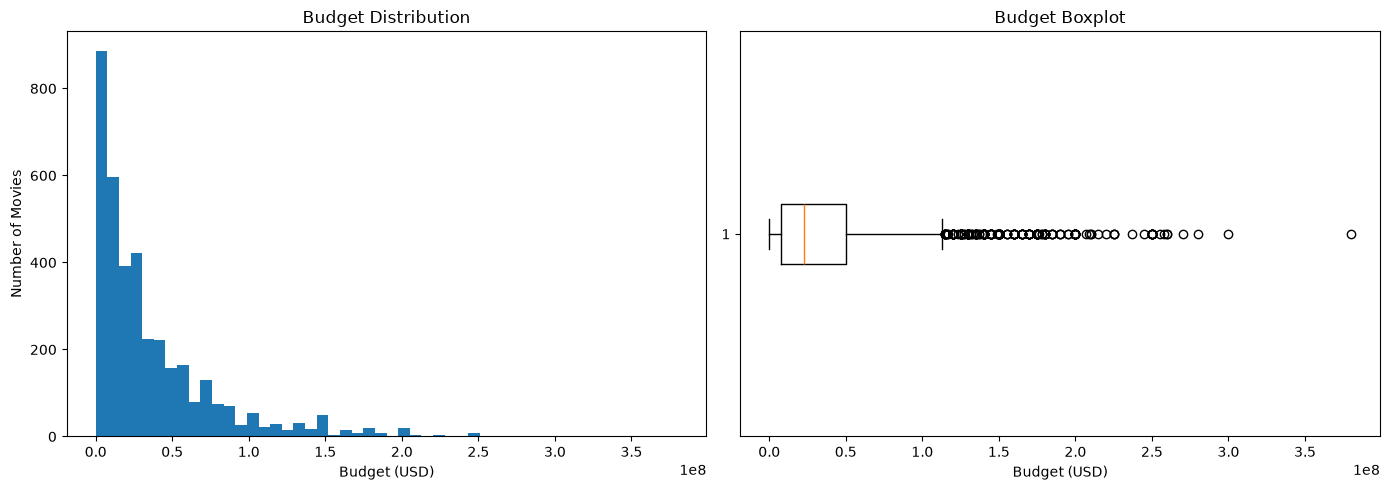

In [100]:
# 📊 Clean budget data (remove missing or zero values)
budget_data = merged_df["budget"]
budget_data = budget_data[budget_data > 0]

# 📐 Create figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(budget_data, bins=50)
axes[0].set_title("Budget Distribution")
axes[0].set_xlabel("Budget (USD)")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(budget_data, vert=False)
axes[1].set_title("Budget Boxplot")
axes[1].set_xlabel("Budget (USD)")

# 📌 Layout adjustment
plt.tight_layout()
plt.show()

#### Top movies by budget

In [101]:
# 📊 Clean data (remove invalid budgets)
budget_df = merged_df[merged_df["budget"] > 0]

# 🏆 Top 10 movies with highest budget
top_budget_movies = budget_df.sort_values("budget", ascending=False).head(10)

# 📋 Display results
print("Top 10 movies by budget:")
display(top_budget_movies[["title", "budget", "release_date", "vote_average"]])

Top 10 movies by budget:


,title,budget,release_date,vote_average
17,Pirates of the Caribbean: On Stranger Tides,380000000.0,2011-05-14,6.4
1,Pirates of the Caribbean: At World's End,300000000.0,2007-05-19,6.9
7,Avengers: Age of Ultron,280000000.0,2015-04-22,7.3
10,Superman Returns,270000000.0,2006-06-28,5.4
4,John Carter,260000000.0,2012-03-07,6.1
6,Tangled,260000000.0,2010-11-24,7.4
5,Spider-Man 3,258000000.0,2007-05-01,5.9
13,The Lone Ranger,255000000.0,2013-07-03,5.9
8,Harry Potter and the Half-Blood Prince,250000000.0,2009-07-07,7.4
3,The Dark Knight Rises,250000000.0,2012-07-16,7.6


### Movies over time 

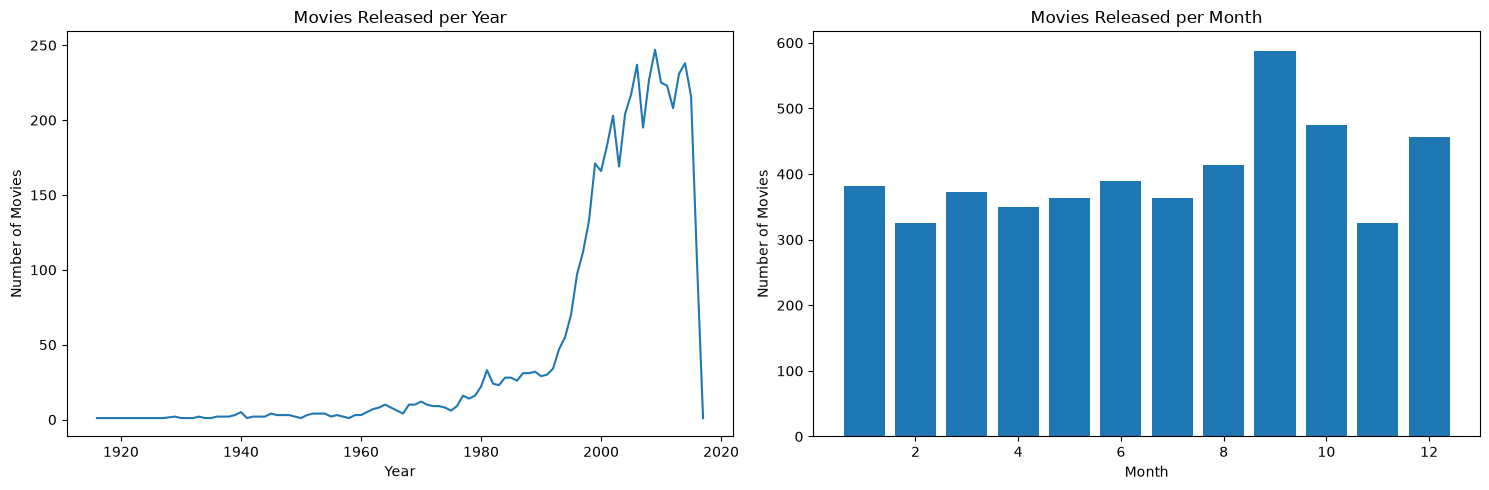

In [102]:
# 📍 Ensure datetime format
merged_df["release_date"] = pd.to_datetime(merged_df["release_date"], errors="coerce")

# 📊 Extract year and month
merged_df["release_year"] = merged_df["release_date"].dt.year
merged_df["release_month"] = merged_df["release_date"].dt.month

# 🔢 Remove missing dates
time_df = merged_df.dropna(subset=["release_year", "release_month"])

# =========================
# 📈 Movies per year
# =========================
movies_per_year = time_df["release_year"].value_counts().sort_index()

# =========================
# 📊 Movies per month
# =========================
movies_per_month = time_df["release_month"].value_counts().sort_index()

# 📐 Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 📈 Plot: movies per year
axes[0].plot(movies_per_year.index, movies_per_year.values)
axes[0].set_title("Movies Released per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Movies")

# 📊 Plot: movies per month
axes[1].bar(movies_per_month.index, movies_per_month.values)
axes[1].set_title("Movies Released per Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Movies")

plt.tight_layout()
plt.show()

#### Create `release_year` and `release_month`

In [103]:
# 📅 Ensure correct datetime format
merged_df["release_date"] = pd.to_datetime(merged_df["release_date"], errors="coerce")

# 🧠 Create time-based features
merged_df["release_year"] = merged_df["release_date"].dt.year
merged_df["release_month"] = merged_df["release_date"].dt.month

# 🔍 Quick check
merged_df[["title", "release_date", "release_year", "release_month"]].head()

,title,release_date,release_year,release_month
0,Avatar,2009-12-10,2009.0,12.0
1,Pirates of the Caribbean: At World's End,2007-05-19,2007.0,5.0
2,Spectre,2015-10-26,2015.0,10.0
3,The Dark Knight Rises,2012-07-16,2012.0,7.0
4,John Carter,2012-03-07,2012.0,3.0


#### Inspect movies with missing `release_date`

In [104]:
# 🔍 Filter rows where release_date is missing (NaT)
missing_release_date = merged_df[merged_df["release_date"].isna()]

# 📊 Summary
print("Number of movies with missing release_date:", len(missing_release_date))

# 👀 Inspect them
display(missing_release_date[["title", "release_date", "release_year", "release_month"]])

Number of movies with missing release_date: 1


,title,release_date,release_year,release_month
4553,America Is Still the Place,NaT,NaN,NaN


### Frequency of original lenguages

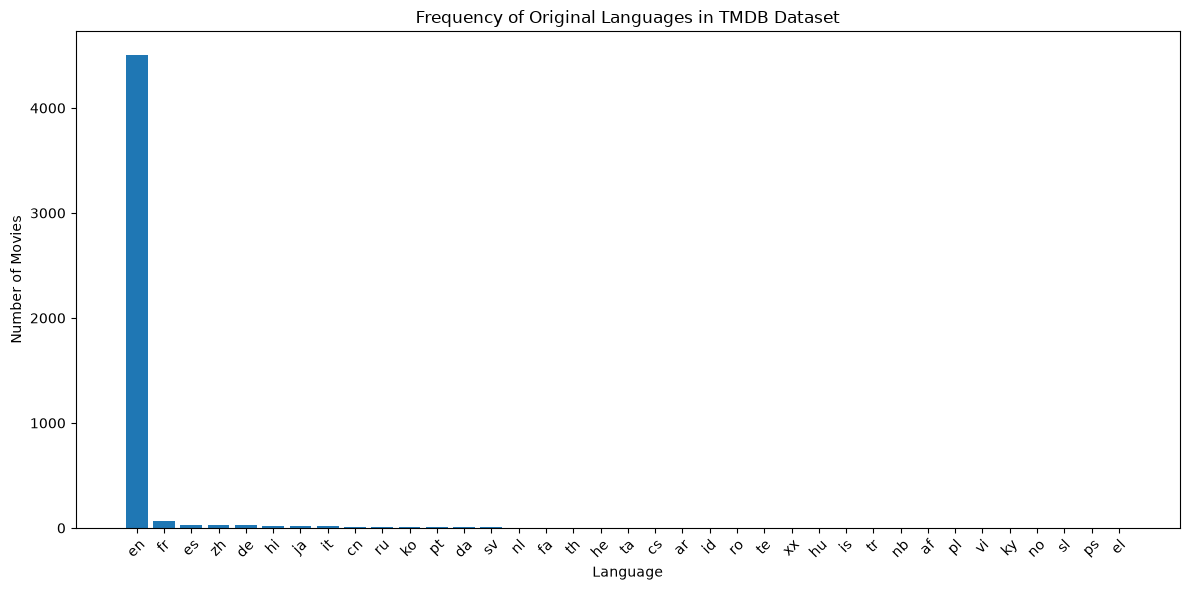

In [105]:
# 📊 Count occurrences of each language
language_counts = merged_df["original_language"].value_counts()

# 📈 Plot
plt.figure(figsize=(12, 6))
plt.bar(language_counts.index, language_counts.values)

# 🏷️ Labels and title
plt.title("Frequency of Original Languages in TMDB Dataset")
plt.xlabel("Language")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Popularity distribution

Count 0s in `popularity`

In [106]:
# 📊 Count zeros in popularity
zero_popularity_count = (merged_df["popularity"] == 0).sum()

print("Number of movies with popularity = 0:", zero_popularity_count)

merged_df[merged_df["popularity"] == 0][
    ["original_title", "budget", "revenue", "popularity", "release_date"]
].head(10)

Number of movies with popularity = 0: 1


,original_title,budget,revenue,popularity,release_date
4553,America Is Still the Place,NaN,0,0.0,NaT


C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\1826501497.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(popularity_data, vert=False)


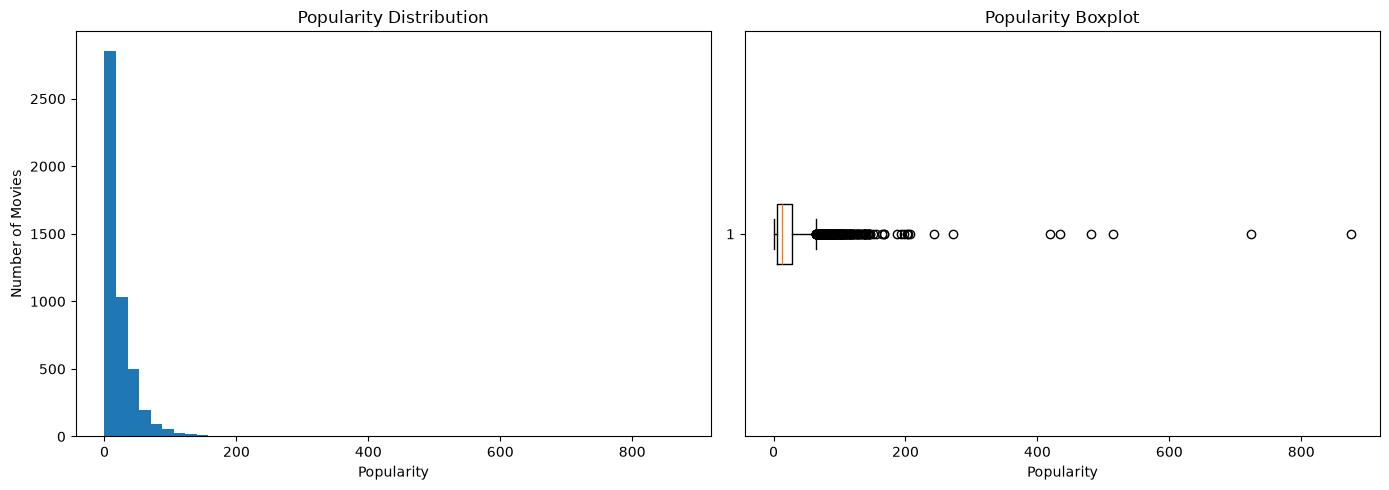

In [107]:
# 📊 Clean popularity data (remove missing or zero/negative values if any)
popularity_data = merged_df["popularity"]
popularity_data = popularity_data[popularity_data > 0]

# 📐 Create figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(popularity_data, bins=50)
axes[0].set_title("Popularity Distribution")
axes[0].set_xlabel("Popularity")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(popularity_data, vert=False)
axes[1].set_title("Popularity Boxplot")
axes[1].set_xlabel("Popularity")

# 📌 Layout adjustment
plt.tight_layout()
plt.show()

#### Top popular movies

In [108]:
# 📊 Clean data (remove invalid budgets)
budget_df = merged_df[merged_df["popularity"] > 0]

# 🏆 Top 10 movies with highest budget
top_budget_movies = budget_df.sort_values("popularity", ascending=False).head(10)

# 📋 Display results
print("Top 10 movies by popularity:")
display(top_budget_movies[["title", "popularity", "budget", "release_date", "vote_average"]])

Top 10 movies by popularity:


,title,popularity,budget,release_date,vote_average
546,Minions,875.581305,74000000.0,2015-06-17,6.4
95,Interstellar,724.247784,165000000.0,2014-11-05,8.1
788,Deadpool,514.569956,58000000.0,2016-02-09,7.4
94,Guardians of the Galaxy,481.098624,170000000.0,2014-07-30,7.9
127,Mad Max: Fury Road,434.278564,150000000.0,2015-05-13,7.2
28,Jurassic World,418.708552,150000000.0,2015-06-09,6.5
199,Pirates of the Caribbean: The Curse of the Bla...,271.972889,140000000.0,2003-07-09,7.5
82,Dawn of the Planet of the Apes,243.791743,170000000.0,2014-06-26,7.3
200,The Hunger Games: Mockingjay - Part 1,206.227151,125000000.0,2014-11-18,6.6
88,Big Hero 6,203.734590,165000000.0,2014-10-24,7.8


### Revenue distribution

Count 0s in `revenue`

In [109]:
# 📊 Count zeros in revenue
zero_revenue_count = (merged_df["revenue"] == 0).sum()

print("Number of movies with revenue = 0:", zero_revenue_count)

merged_df[merged_df["revenue"] == 0][
    ["original_title", "budget", "revenue", "popularity", "release_date"]
].head(10)

Number of movies with revenue = 0: 1427


,original_title,budget,revenue,popularity,release_date
83,The Lovers,27000000.0,0,2.418535,2015-02-13
135,The Wolfman,150000000.0,0,21.214571,2010-02-11
265,The Cat in the Hat,NaN,0,18.251129,2003-11-21
309,Son of the Mask,84000000.0,0,17.815595,2005-02-18
376,Volcano,90000000.0,0,19.836124,1997-04-25
406,Arthur Christmas,NaN,0,19.836830,2011-02-22
433,RED 2,84000000.0,0,44.343330,2013-07-18
453,The Pink Panther,NaN,0,25.450534,2006-01-18
463,Déjà Vu,NaN,0,0.605645,1998-04-22
467,Mighty Joe Young,90000000.0,0,6.643778,1998-12-25


We will replace the value **0 in the `revenue` column with `NaN`** because a revenue of zero is not realistic for most commercially released films in this dataset.

In most cases, these zeros do not represent an actual box office revenue of 0 USD, but rather missing, unavailable, or unreported financial information in the dataset.

By converting these values to `NaN`, we explicitly treat them as missing data, which helps avoid misleading statistical summaries and ensures a more accurate and reliable financial analysis.

In [110]:
merged_df["revenue"] = merged_df["revenue"].replace(0, np.nan)

Distribution of `revenue`

C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\3616900372.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(revenue_data, vert=False)


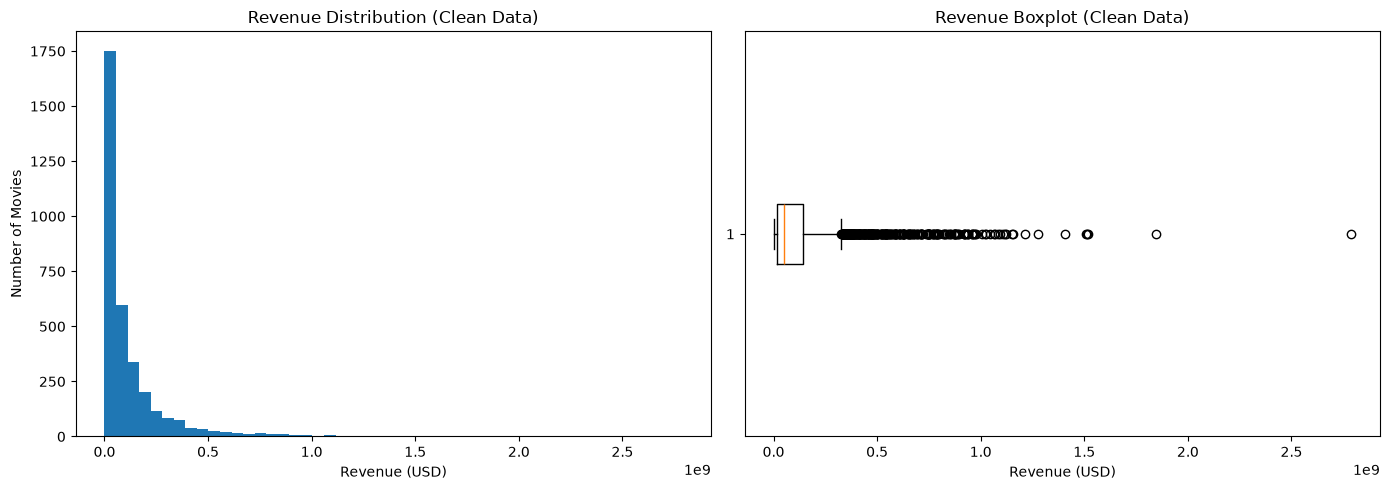

In [111]:
# 📊 Clean revenue data (0 already treated as missing -> NaN)
revenue_data = merged_df["revenue"].dropna()

# 📐 Create figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(revenue_data, bins=50)
axes[0].set_title("Revenue Distribution (Clean Data)")
axes[0].set_xlabel("Revenue (USD)")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(revenue_data, vert=False)
axes[1].set_title("Revenue Boxplot (Clean Data)")
axes[1].set_xlabel("Revenue (USD)")

# 📌 Layout adjustment
plt.tight_layout()
plt.show()

#### Top movies by revenue

In [112]:
# 📊 Clean data (remove invalid budgets)
budget_df = merged_df[merged_df["revenue"] > 0]

# 🏆 Top 10 movies with highest budget
top_budget_movies = budget_df.sort_values("revenue", ascending=False).head(10)

# 📋 Display results
print("Top 10 movies by budget:")
display(top_budget_movies[["title", "revenue", "budget", "release_date", "vote_average"]])

Top 10 movies by budget:


,title,revenue,budget,release_date,vote_average
0,Avatar,2.787965e+09,237000000.0,2009-12-10,7.2
25,Titanic,1.845034e+09,200000000.0,1997-11-18,7.5
16,The Avengers,1.519558e+09,220000000.0,2012-04-25,7.4
28,Jurassic World,1.513529e+09,150000000.0,2015-06-09,6.5
44,Furious 7,1.506249e+09,190000000.0,2015-04-01,7.3
7,Avengers: Age of Ultron,1.405404e+09,280000000.0,2015-04-22,7.3
124,Frozen,1.274219e+09,150000000.0,2013-11-27,7.3
31,Iron Man 3,1.215440e+09,200000000.0,2013-04-18,6.8
546,Minions,1.156731e+09,74000000.0,2015-06-17,6.4
26,Captain America: Civil War,1.153304e+09,250000000.0,2016-04-27,7.1


### Creation of `profit` column

In [113]:
merged_df["profit"] = merged_df["revenue"] - merged_df["budget"]

#### Distribution of `profit`

C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\1296573633.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(profit_data, vert=False)


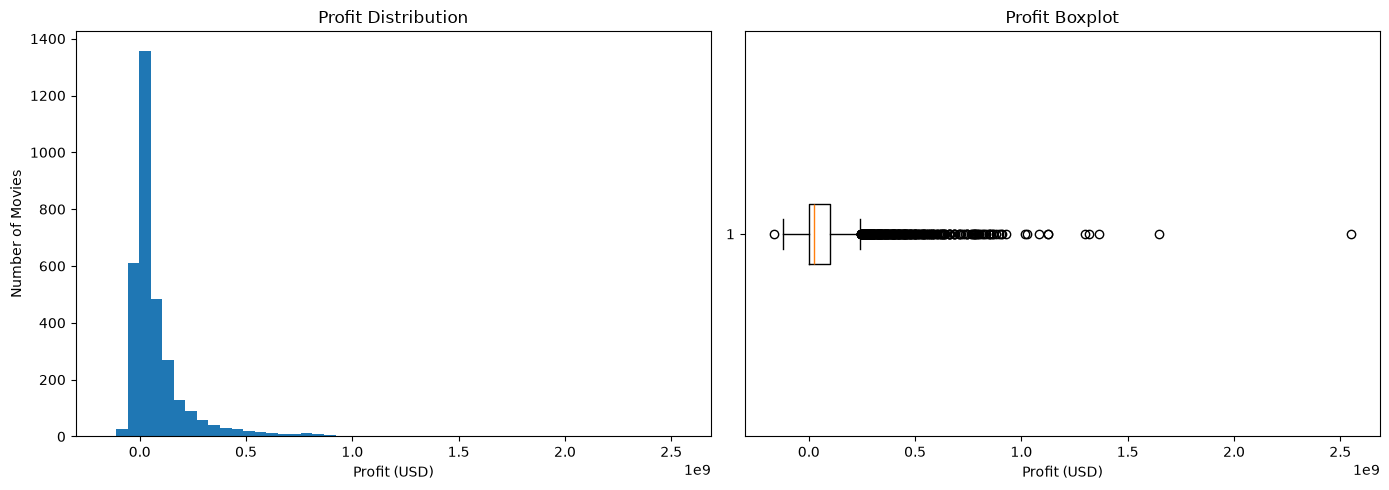

In [114]:
# 📊 Clean data for plotting
profit_data = merged_df["profit"].dropna()

# 📐 Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(profit_data, bins=50)
axes[0].set_title("Profit Distribution")
axes[0].set_xlabel("Profit (USD)")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(profit_data, vert=False)
axes[1].set_title("Profit Boxplot")
axes[1].set_xlabel("Profit (USD)")

# 📌 Layout adjustment
plt.tight_layout()
plt.show()

#### Top 10 most & least profitable movies

In [115]:
# 📊 Remove rows where profit is NaN
profit_df = merged_df.dropna(subset=["profit"])

# 🏆 Top 10 most profitable movies
top_10_profit = profit_df.sort_values("profit", ascending=False).head(10)

# 📉 Top 10 least profitable movies
bottom_10_profit = profit_df.sort_values("profit", ascending=True).head(10)

print("🏆 TOP 10 MOST PROFITABLE MOVIES")
display(top_10_profit[["original_title", "budget", "revenue", "profit"]])

print("\n📉 TOP 10 LEAST PROFITABLE MOVIES")
display(bottom_10_profit[["original_title", "budget", "revenue", "profit"]])

🏆 TOP 10 MOST PROFITABLE MOVIES


,original_title,budget,revenue,profit
0,Avatar,237000000.0,2.787965e+09,2.550965e+09
25,Titanic,200000000.0,1.845034e+09,1.645034e+09
28,Jurassic World,150000000.0,1.513529e+09,1.363529e+09
44,Furious 7,190000000.0,1.506249e+09,1.316249e+09
16,The Avengers,220000000.0,1.519558e+09,1.299558e+09
7,Avengers: Age of Ultron,280000000.0,1.405404e+09,1.125404e+09
124,Frozen,150000000.0,1.274219e+09,1.124219e+09
546,Minions,74000000.0,1.156731e+09,1.082731e+09
329,The Lord of the Rings: The Return of the King,94000000.0,1.118889e+09,1.024889e+09
31,Iron Man 3,200000000.0,1.215440e+09,1.015440e+09



📉 TOP 10 LEAST PROFITABLE MOVIES


,original_title,budget,revenue,profit
13,The Lone Ranger,255000000.0,89289910.0,-165710090.0
338,The Alamo,145000000.0,25819961.0,-119180039.0
141,Mars Needs Moms,150000000.0,38992758.0,-111007242.0
208,The 13th Warrior,160000000.0,61698899.0,-98301101.0
311,The Adventures of Pluto Nash,100000000.0,7103973.0,-92896027.0
2638,Metropolis,92620000.0,650422.0,-91969578.0
340,Cutthroat Island,98000000.0,10017322.0,-87982678.0
142,Flushed Away,149000000.0,64459316.0,-84540684.0
192,Australia,130000000.0,49554002.0,-80445998.0
272,Town & Country,90000000.0,10372291.0,-79627709.0


### Distribution of `status`

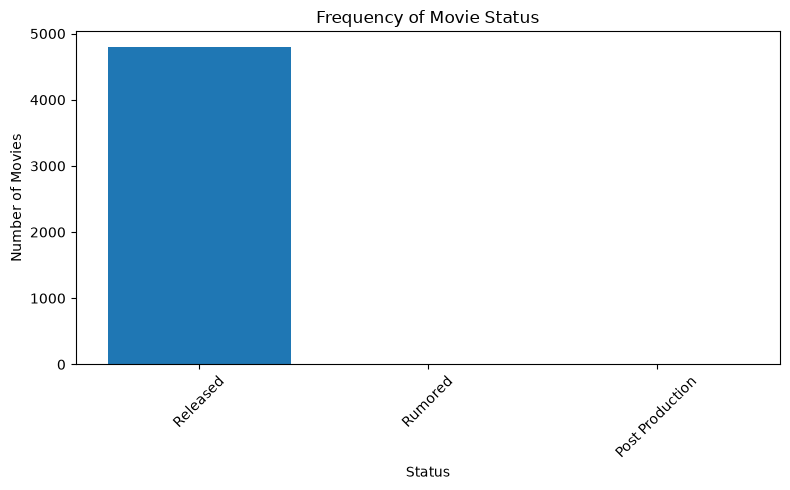

In [116]:
# 📊 Count occurrences of each movie status
status_counts = merged_df["status"].value_counts()

# 📈 Plot
plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values)

# 🏷️ Labels and title
plt.title("Frequency of Movie Status")
plt.xlabel("Status")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
merged_df["status"].value_counts()

status
Released           4795
Rumored               5
Post Production       3
Name: count, dtype: int64

In [118]:
merged_df[merged_df["status"].isin(["Rumored", "Post Production"])][
    ["original_title", "status", "release_date", "budget", "revenue", "vote_count", "vote_average"]
].sort_values("status")

,original_title,status,release_date,budget,revenue,vote_count,vote_average
2906,Dancin' It's On,Post Production,2015-10-16,NaN,NaN,2,4.3
4169,Brotherly Love,Post Production,2015-04-24,1900000.0,NaN,21,6.9
4178,Higher Ground,Post Production,2011-08-26,2000000.0,841733.0,14,5.3
4401,The Helix... Loaded,Rumored,2005-01-01,NaN,NaN,2,4.8
4453,Crying with Laughter,Rumored,2009-06-01,NaN,NaN,1,7.0
4508,The Harvest (La Cosecha),Rumored,2011-07-29,56000.0,NaN,0,0.0
4662,Little Big Top,Rumored,2006-01-01,NaN,NaN,1,10.0
4754,The Naked Ape,Rumored,2006-09-16,NaN,NaN,1,5.0


Although the `status` column contains categories other than **Released** (such as **Rumored** or **Post Production**), these entries often have valid values for other variables, including `vote_average`, `vote_count`, `popularity`, and sometimes even financial information.

This suggests that the dataset may contain inconsistencies caused by updates made at different points in time. In other words, the movie information appears to have been updated after the initial record was created, while the `status` field remained unchanged.

Since the remaining attributes contain meaningful information, these movies will be retained in the dataset and included in the analysis.

### Distribution of `runtime`

#### Missing and 0 values

In [119]:
# 📊 Count missing and zero values in runtime
missing_runtime = merged_df["runtime"].isna().sum()
zero_runtime = (merged_df["runtime"] == 0).sum()

print(f"Missing values (NaN): {missing_runtime}")
print(f"Zero values: {zero_runtime}")

Missing values (NaN): 2
Zero values: 35


In [120]:
merged_df.loc[
    (merged_df["runtime"].isna()) | (merged_df["runtime"] == 0),
    ["original_title", "runtime", "status", "release_date", "budget", "revenue"]
]

,original_title,runtime,status,release_date,budget,revenue
1011,The Tooth Fairy,0.0,Released,2006-08-08,NaN,NaN
2656,Chiamatemi Francesco - Il Papa della gente,NaN,Released,2015-12-03,15000000.0,NaN
3112,Blood Done Sign My Name,0.0,Released,2010-02-01,NaN,NaN
3669,Should've Been Romeo,0.0,Released,2012-04-28,NaN,NaN
3809,How to Fall in Love,0.0,Released,2012-07-21,4000000.0,NaN
3953,Fort McCoy,0.0,Released,2014-01-01,NaN,NaN
3992,Sardaarji,0.0,Released,2015-06-26,NaN,NaN
4068,Sharkskin,0.0,Released,2015-01-01,NaN,NaN
4118,Hum To Mohabbat Karega,0.0,Released,2000-05-26,NaN,NaN
4140,"To Be Frank, Sinatra at 100",NaN,Released,2015-12-12,2.0,NaN


We will replace the value **0 in the `runtime` column with `NaN`** because a runtime of zero minutes is not realistic for any valid film in the dataset.

In most cases, these zero values do not represent an actual movie duration of 0 minutes, but rather missing, unknown, or unrecorded information in the dataset.

By converting these values to `NaN`, we ensure that missing data is properly represented, avoiding misleading summaries and allowing for more accurate statistical analysis of movie durations.

In [121]:
merged_df["runtime"] = merged_df["runtime"].replace(0, np.nan)

C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\854666010.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(runtime_data, vert=False)


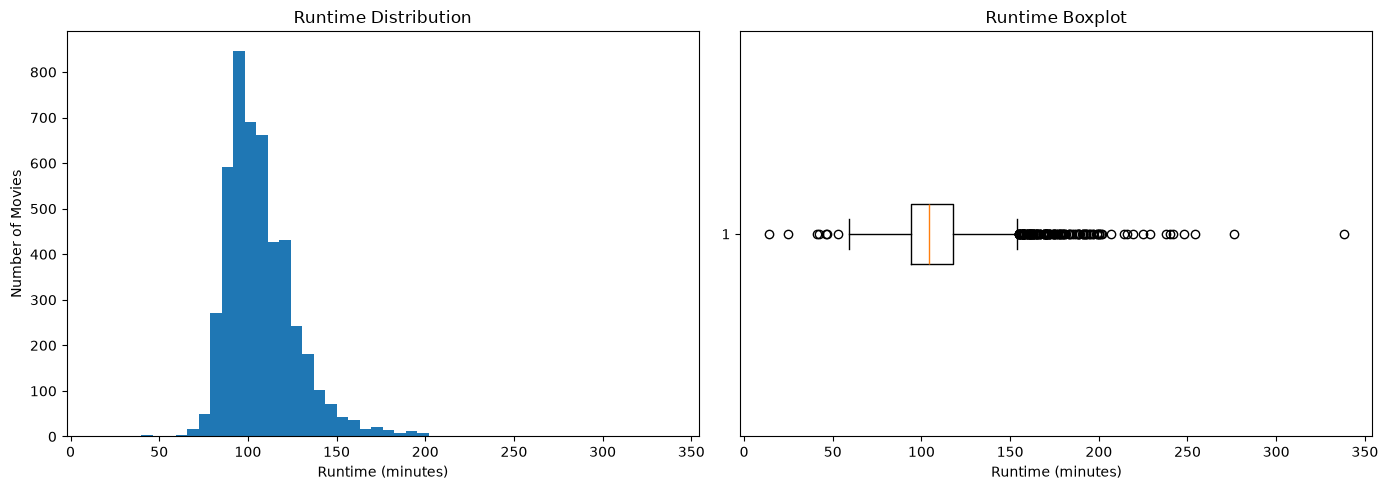

In [122]:
# 📊 Clean data (NaN already represents missing or invalid values)
runtime_data = merged_df["runtime"].dropna()

# 📐 Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(runtime_data, bins=50)
axes[0].set_title("Runtime Distribution")
axes[0].set_xlabel("Runtime (minutes)")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(runtime_data, vert=False)
axes[1].set_title("Runtime Boxplot")
axes[1].set_xlabel("Runtime (minutes)")

# 📌 Layout adjustment
plt.tight_layout()
plt.show()

#### Shortest and longest movies

In [123]:
# 📊 Drop NaN runtime values
runtime_df = merged_df.dropna(subset=["runtime"])

# 🏆 Top 10 longest movies
top_10_longest = runtime_df.sort_values("runtime", ascending=False).head(10)

top_10_longest[["original_title", "runtime", "release_date", "budget", "revenue"]]

,original_title,runtime,release_date,budget,revenue
2384,Carlos,338.0,2010-05-19,18000000.0,871279.0
2631,The Company,276.0,2007-08-05,NaN,NaN
1922,Gettysburg,254.0,1993-10-08,NaN,25000000.0
1125,Cleopatra,248.0,1963-06-12,31115000.0,71000000.0
2373,Hamlet,242.0,1996-12-25,NaN,NaN
3510,Emma,240.0,2009-10-11,NaN,NaN
3813,Gone with the Wind,238.0,1939-12-15,4000000.0,400176459.0
1663,Once Upon a Time in America,229.0,1984-02-16,30000000.0,NaN
4497,Woodstock,225.0,1970-03-26,600000.0,34505110.0
1109,Heaven's Gate,219.0,1980-11-19,44000000.0,3484331.0


In [124]:
# 📉 Top 10 shortest movies
top_10_shortest = runtime_df.sort_values("runtime", ascending=True).head(10)

top_10_shortest[["original_title", "runtime", "release_date", "budget", "revenue"]]

,original_title,runtime,release_date,budget,revenue
4466,Vessel,14.0,2012-10-28,NaN,NaN
4709,A Charlie Brown Christmas,25.0,1965-12-09,NaN,NaN
3626,Sea Rex 3D: Journey to a Prehistoric World,41.0,2010-05-14,5000000.0,4074023.0
3471,Dolphins and Whales: Tribes of the Ocean,42.0,2008-02-15,6000000.0,7518876.0
3354,Michael Jordan to the Max,46.0,2000-05-05,NaN,21268532.0
4756,The Call of Cthulhu,47.0,2005-01-01,50000.0,NaN
3403,Alpha and Omega: The Legend of the Saw Tooth Cave,53.0,2014-07-21,NaN,NaN
4685,Chats perchés,59.0,2004-12-05,NaN,NaN
4785,Stories of Our Lives,60.0,2014-09-05,NaN,NaN
1620,Winnie the Pooh,63.0,2011-04-13,30000000.0,14460000.0


### Column `vote_count`

C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\618252340.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(vote_count_data, vert=False)


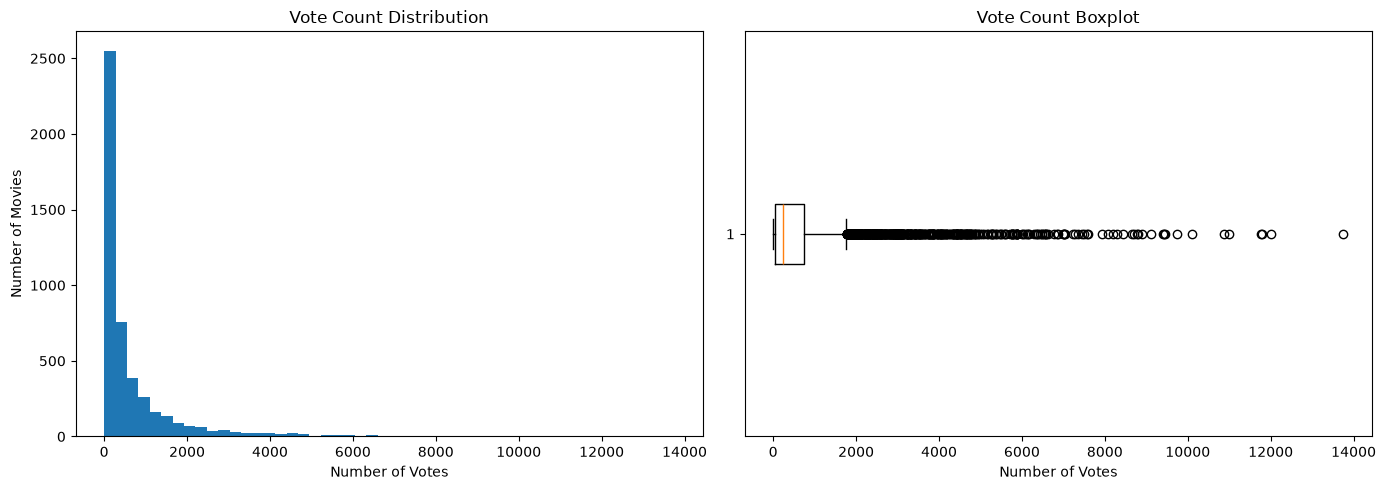

In [125]:
# 📊 Clean data (remove NaN just in case)
vote_count_data = merged_df["vote_count"].dropna()

# 📐 Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(vote_count_data, bins=50)
axes[0].set_title("Vote Count Distribution")
axes[0].set_xlabel("Number of Votes")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(vote_count_data, vert=False)
axes[1].set_title("Vote Count Boxplot")
axes[1].set_xlabel("Number of Votes")

plt.tight_layout()
plt.show()

#### Most voted

In [126]:
# 📊 Drop NaN runtime values
runtime_df = merged_df.dropna(subset=["vote_count"])

# 🏆 Top 10 voted movies
top_10_longest = runtime_df.sort_values("vote_count", ascending=False).head(10)

top_10_longest[["title", "vote_count", "release_date", "budget", "revenue"]]

,title,vote_count,release_date,budget,revenue
96,Inception,13752,2010-07-14,160000000.0,8.255328e+08
65,The Dark Knight,12002,2008-07-16,185000000.0,1.004558e+09
0,Avatar,11800,2009-12-10,237000000.0,2.787965e+09
16,The Avengers,11776,2012-04-25,220000000.0,1.519558e+09
788,Deadpool,10995,2016-02-09,58000000.0,7.831130e+08
95,Interstellar,10867,2014-11-05,165000000.0,6.751200e+08
287,Django Unchained,10099,2012-12-25,100000000.0,4.253682e+08
94,Guardians of the Galaxy,9742,2014-07-30,170000000.0,7.733286e+08
426,The Hunger Games,9455,2012-03-12,75000000.0,6.912107e+08
127,Mad Max: Fury Road,9427,2015-05-13,150000000.0,3.788583e+08


### Column `vote_average`

Firstly, we check if all the rows with `vote_average`= 0 also have `vote_count`= 0 or there is any exception.

In [127]:
# 🔍 Check if ALL movies with vote_average = 0 also have vote_count = 0

result = (merged_df.loc[merged_df["vote_average"] == 0, "vote_count"] == 0).all()

print("Do all rows with vote_average = 0 have vote_count = 0?")
print(result)

Do all rows with vote_average = 0 have vote_count = 0?
False


In [128]:
# 🔍 Rows where vote_average = 0
subset = merged_df[merged_df["vote_average"] == 0]

# ❓ Check condition
result = (subset["vote_count"] == 0).all()

print("Do all rows with vote_average = 0 have vote_count = 0?")
print(result)

# 🚨 If not, show the problematic rows
if not result:
    exceptions = subset[subset["vote_count"] != 0]
    display(exceptions[["original_title", "vote_average", "vote_count", "status"]])

Do all rows with vote_average = 0 have vote_count = 0?
False


,original_title,vote_average,vote_count,status
4400,Sparkler,0.0,1,Released


C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\2527030968.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(vote_avg_data, vert=False)


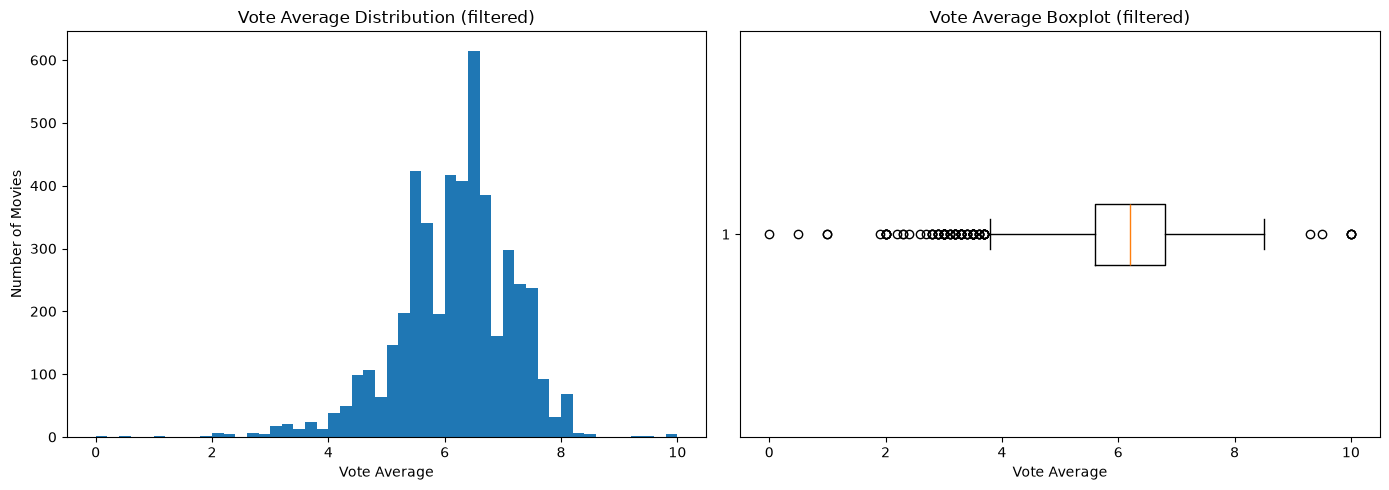

In [129]:
# 📊 Clean data (keep only meaningful ratings)
vote_avg_data = merged_df.loc[merged_df["vote_count"] > 0, "vote_average"].dropna()

# 📐 Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(vote_avg_data, bins=50)
axes[0].set_title("Vote Average Distribution (filtered)")
axes[0].set_xlabel("Vote Average")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(vote_avg_data, vert=False)
axes[1].set_title("Vote Average Boxplot (filtered)")
axes[1].set_xlabel("Vote Average")

plt.tight_layout()
plt.show()

#### Highest & lowest rated movies

In [130]:
# 📊 Filter valid ratings
ratings_df = merged_df[merged_df["vote_count"] > 0].copy()

# 🏆 Top 10 highest rated movies
top_10_rated = ratings_df.sort_values("vote_average", ascending=False).head(10)

top_10_rated[["original_title", "vote_average", "vote_count", "popularity", "release_date"]]

,original_title,vote_average,vote_count,popularity,release_date
3519,Stiff Upper Lips,10.0,1,0.356495,1998-06-12
4247,Me You and Five Bucks,10.0,2,0.094105,2015-07-07
4662,Little Big Top,10.0,1,0.092100,2006-01-01
4045,"Dancer, Texas Pop. 81",10.0,1,0.376662,1998-05-01
3992,Sardaarji,9.5,2,0.296981,2015-06-26
2386,One Man's Hero,9.3,2,0.910529,1999-08-02
2970,There Goes My Baby,8.5,2,0.037073,1994-09-02
1881,The Shawshank Redemption,8.5,8205,136.747729,1994-09-23
2796,The Prisoner of Zenda,8.4,11,4.021389,1937-09-03
3337,The Godfather,8.4,5893,143.659698,1972-03-14


In [131]:
# 📉 Top 10 lowest rated movies
bottom_10_rated = ratings_df.sort_values("vote_average", ascending=True).head(10)

bottom_10_rated[["original_title", "vote_average", "vote_count", "popularity", "release_date"]]

,original_title,vote_average,vote_count,popularity,release_date
4400,Sparkler,0.0,1,0.547654,1999-03-19
2272,Dwegons,0.5,1,0.485405,2014-01-24
4581,Gory Gory Hallelujah,1.0,1,0.033883,2003-11-05
3689,All Hat,1.0,1,0.137535,2007-09-11
2220,Superbabies: Baby Geniuses 2,1.9,35,5.886228,2004-08-27
4791,Tin Can Man,2.0,1,0.332679,2007-01-01
4318,Bleeding Hearts,2.0,1,0.100533,2013-06-01
4764,Dawn of the Crescent Moon,2.0,1,0.049469,2014-04-05
4562,The Little Ponderosa Zoo,2.0,1,0.073079,2014-09-11
4451,Windsor Drive,2.0,1,0.504251,2015-06-26


### ⭐ Weighted Rating (IMDb-style ranking)

To build a more reliable movie rating system, we use a **weighted rating formula** similar to the one used by IMDb. This approach takes into account not only the average rating of a movie, but also the number of votes it has received, giving more importance to movies with a larger number of ratings.

#### 📌 Formula

$$
WR = \frac{v}{v + m} \cdot R + \frac{m}{v + m} \cdot C
$$

Where:

- **v** = number of votes (vote_count)  
- **R** = average rating of the movie (vote_average)  
- **C** = mean vote across the whole dataset  
- **m** = minimum number of votes required to be considered  

#### 🧠 Intuition

- Movies with **few votes** are pulled closer to the global average (C).  
- Movies with **many votes** rely more on their own rating (R).  
- This prevents highly rated but low-vote movies from ranking unfairly high.  

In [132]:
# 📊 Work on a copy to avoid modifying original unintentionally
df = merged_df.copy()

# 📌 Global mean rating (C)
C = df["vote_average"].mean()

# 📌 Minimum votes threshold (m = 10th percentile)
m = df["vote_count"].quantile(0.10)

# 🖨️ Show threshold value
print(f"Minimum votes threshold (m - 10th percentile): {m:.0f}")

# 🏆 Filter movies above threshold
qualified = df[df["vote_count"] >= m].copy()

# 📊 Weighted rating formula
v = qualified["vote_count"]
R = qualified["vote_average"]

qualified["weighted_rating"] = (v / (v + m)) * R + (m / (v + m)) * C

# 🔗 Merge back into original dataframe
merged_df = merged_df.merge(
    qualified[["weighted_rating"]],
    left_index=True,
    right_index=True,
    how="left"
)

Minimum votes threshold (m - 10th percentile): 12


C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\2462890699.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(wr_data, vert=False)


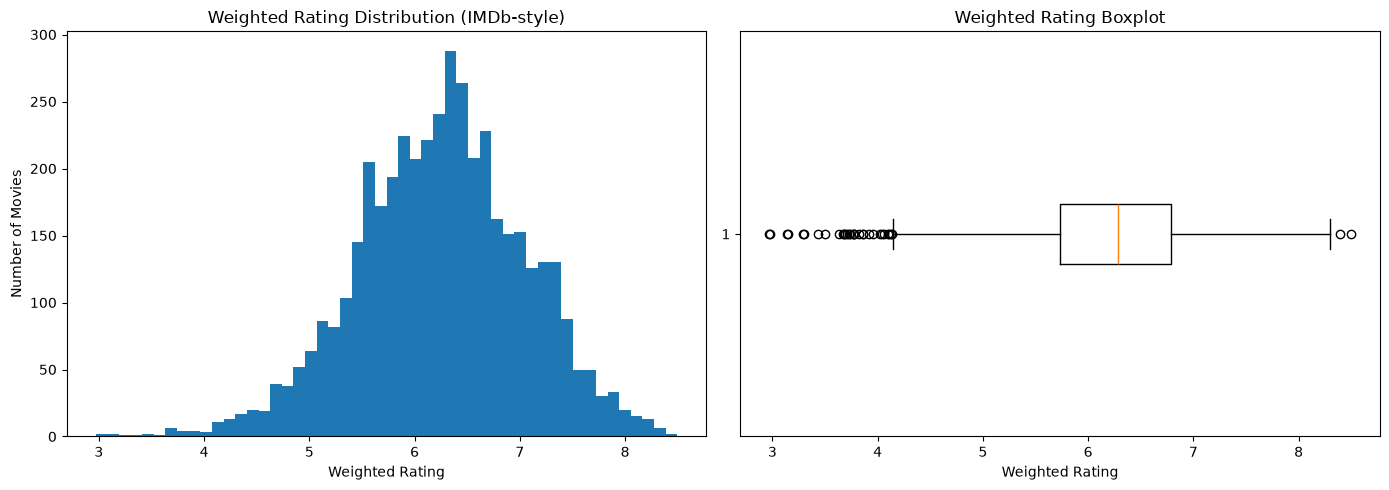

In [133]:
# 📊 Clean data (remove NaN from movies below threshold)
wr_data = merged_df["weighted_rating"].dropna()

# 📐 Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(wr_data, bins=50)
axes[0].set_title("Weighted Rating Distribution (IMDb-style)")
axes[0].set_xlabel("Weighted Rating")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(wr_data, vert=False)
axes[1].set_title("Weighted Rating Boxplot")
axes[1].set_xlabel("Weighted Rating")

plt.tight_layout()
plt.show()

In [136]:
print(f"C (global mean rating): {C:.2f}")
print(f"m (10th percentile vote_count): {m:.0f}")
print(f"Number of qualified movies: {len(qualified)}")

C (global mean rating): 6.09
m (10th percentile vote_count): 12
Number of qualified movies: 4326


In [134]:
top_10_wr = merged_df.dropna(subset=["weighted_rating"]) \
    .sort_values("weighted_rating", ascending=False) \
    .head(10)

top_10_wr[["title", "vote_count", "vote_average", "weighted_rating"]]

,title,vote_count,vote_average,weighted_rating
1881,The Shawshank Redemption,8205,8.5,8.496484
3337,The Godfather,5893,8.4,8.395310
662,Fight Club,9413,8.3,8.297189
3232,Pulp Fiction,8428,8.3,8.296861
1818,Schindler's List,4329,8.3,8.293897
3865,Whiplash,4254,8.3,8.293790
2294,Spirited Away,3840,8.3,8.293122
2731,The Godfather: Part II,3338,8.3,8.292091
65,The Dark Knight,12002,8.2,8.197895
809,Forrest Gump,7927,8.2,8.196814


In [135]:
bottom_10_wr = merged_df.dropna(subset=["weighted_rating"]) \
    .sort_values("weighted_rating", ascending=True) \
    .head(10)

bottom_10_wr[["title", "vote_count", "vote_average", "weighted_rating"]]

,title,vote_count,vote_average,weighted_rating
2220,Superbabies: Baby Geniuses 2,35,1.9,2.970342
1652,Dragonball Evolution,462,2.9,2.980814
480,Battlefield Earth,255,3.0,3.138974
2194,Disaster Movie,240,3.0,3.147246
2237,Alone in the Dark,173,3.1,3.294087
2122,Epic Movie,326,3.2,3.302681
1101,Foodfight!,28,2.3,3.437651
1265,FearDotCom,105,3.2,3.496633
2003,Jaws: The Revenge,224,3.5,3.631805
601,Rollerball,106,3.4,3.673780


### Column `keywords`

#### Missing values

In [137]:
# 📊 Count missing values
missing_keywords = merged_df["keywords"].isna().sum()

# 📊 Count empty keyword lists
empty_keywords = (merged_df["keywords"] == "[]").sum()

print(f"Missing values (NaN): {missing_keywords}")
print(f"Empty keyword lists ([]): {empty_keywords}")

Missing values (NaN): 0
Empty keyword lists ([]): 412


#### Consistency of IDs

In [144]:
# 📊 Parse keywords without modifying the original dataframe
keywords_parsed = merged_df["keywords"].fillna("[]").apply(ast.literal_eval)

# 📊 Dictionary: keyword ID -> set of names
id_to_names = defaultdict(set)

for keywords in keywords_parsed:
    for kw in keywords:
        id_to_names[kw["id"]].add(kw["name"])

# 🔍 IDs associated with more than one name
inconsistent_ids = {
    keyword_id: names
    for keyword_id, names in id_to_names.items()
    if len(names) > 1
}

print(f"Number of inconsistent keyword IDs: {len(inconsistent_ids)}")

if inconsistent_ids:
    display(inconsistent_ids)

Number of inconsistent keyword IDs: 0


In [154]:
# 📊 Dictionary: keyword name -> set of IDs
name_to_ids = defaultdict(set)

for keywords in keywords_parsed:
    for kw in keywords:
        name_to_ids[kw["name"]].add(kw["id"])

# 🔍 Keyword names associated with more than one ID
inconsistent_names = {
    keyword_name: ids
    for keyword_name, ids in name_to_ids.items()
    if len(ids) > 1
}

print(f"Number of keyword names associated with multiple IDs: {len(inconsistent_names)}")

if inconsistent_names:
    display(inconsistent_names)

Number of keyword names associated with multiple IDs: 0


#### Most frequent Keywords

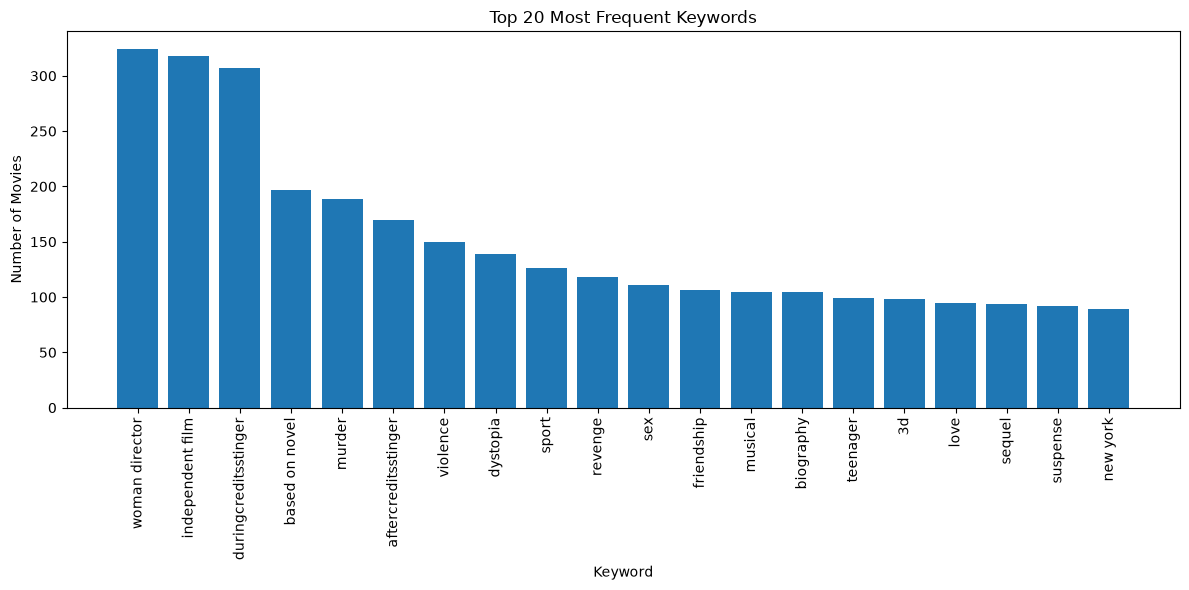

In [146]:
# 📊 Count keyword occurrences
keyword_counts = Counter()

for keywords in keywords_parsed:
    for kw in keywords:
        keyword_counts[kw["name"]] += 1

# 🔝 Top 20 most frequent keywords
top_keywords = keyword_counts.most_common(20)

# 📈 Plot
plt.figure(figsize=(12, 6))
plt.bar(
    [k[0] for k in top_keywords],
    [k[1] for k in top_keywords]
)

# 🏷️ Labels and title
plt.title("Top 20 Most Frequent Keywords")
plt.xlabel("Keyword")
plt.ylabel("Number of Movies")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Keywords per movie

C:\Users\Darío\AppData\Local\Temp\ipykernel_14240\479023746.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(keyword_counts, vert=False)


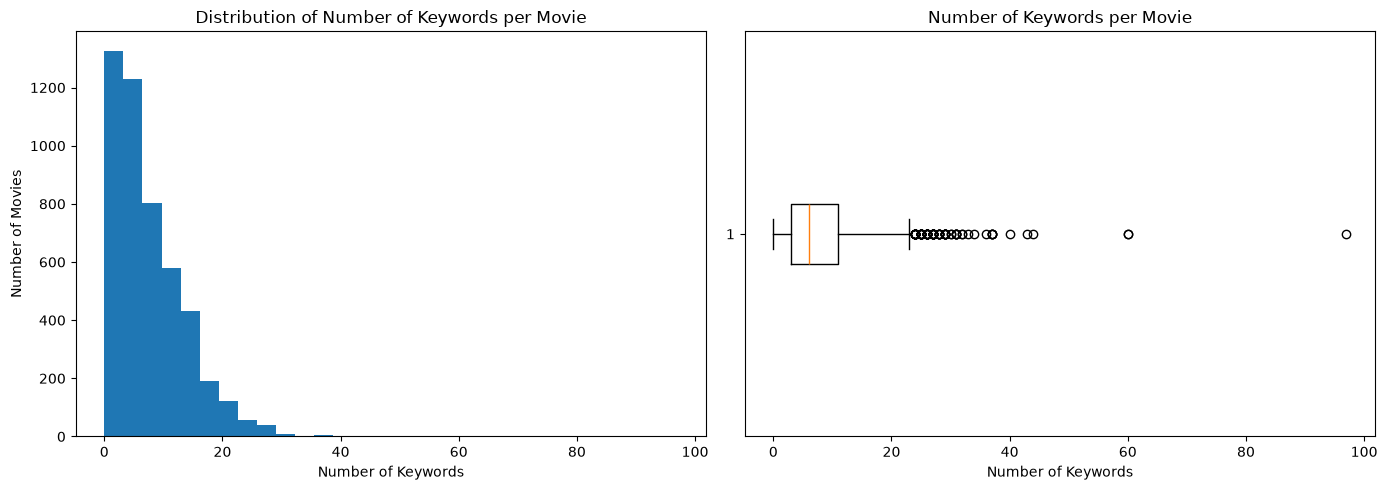

In [147]:
# 📊 Count the number of keywords for each movie
keyword_counts = keywords_parsed.apply(len)

# 📐 Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📊 Histogram
axes[0].hist(keyword_counts, bins=30)
axes[0].set_title("Distribution of Number of Keywords per Movie")
axes[0].set_xlabel("Number of Keywords")
axes[0].set_ylabel("Number of Movies")

# 📦 Boxplot
axes[1].boxplot(keyword_counts, vert=False)
axes[1].set_title("Number of Keywords per Movie")
axes[1].set_xlabel("Number of Keywords")

plt.tight_layout()
plt.show()

In [148]:
# 🏆 Top 10 movies with the most keywords
merged_df.assign(num_keywords=keyword_counts) \
         .sort_values("num_keywords", ascending=False) \
         [["original_title", "num_keywords"]] \
         .head(10)

,original_title,num_keywords
2428,Brooklyn's Finest,97
2217,Everyone Says I Love You,60
2442,Southland Tales,60
1696,Straight Outta Compton,44
1133,15 Minutes,43
4436,Hard Candy,40
3746,The Boy Next Door,37
3357,The Devil's Rejects,37
884,Zero Dark Thirty,37
139,Mission: Impossible III,37


### Column `production companies`

In [149]:
# 📊 Display complete examples of the production_companies column
for i, companies in enumerate(merged_df["production_companies"].head(5), start=1):
    print(f"Movie {i}:")
    print(companies)
    print("-" * 100)

Movie 1:
[{"name": "Ingenious Film Partners", "id": 289}, {"name": "Twentieth Century Fox Film Corporation", "id": 306}, {"name": "Dune Entertainment", "id": 444}, {"name": "Lightstorm Entertainment", "id": 574}]
----------------------------------------------------------------------------------------------------
Movie 2:
[{"name": "Walt Disney Pictures", "id": 2}, {"name": "Jerry Bruckheimer Films", "id": 130}, {"name": "Second Mate Productions", "id": 19936}]
----------------------------------------------------------------------------------------------------
Movie 3:
[{"name": "Columbia Pictures", "id": 5}, {"name": "Danjaq", "id": 10761}, {"name": "B24", "id": 69434}]
----------------------------------------------------------------------------------------------------
Movie 4:
[{"name": "Legendary Pictures", "id": 923}, {"name": "Warner Bros.", "id": 6194}, {"name": "DC Entertainment", "id": 9993}, {"name": "Syncopy", "id": 9996}]
------------------------------------------------------

#### Missing values

In [150]:
# 📊 Count missing values
missing_companies = merged_df["production_companies"].isna().sum()

# 📊 Count empty lists
empty_companies = (merged_df["production_companies"] == "[]").sum()

print(f"Missing values (NaN): {missing_companies}")
print(f"Empty company lists ([]): {empty_companies}")

Missing values (NaN): 0
Empty company lists ([]): 351


In [152]:
# 📊 Parse production companies without modifying the original dataframe
companies_parsed = merged_df["production_companies"].fillna("[]").apply(ast.literal_eval)

# 📊 Dictionary: company ID -> set of names
id_to_names = defaultdict(set)

for companies in companies_parsed:
    for company in companies:
        id_to_names[company["id"]].add(company["name"])

# 🔍 IDs associated with more than one company name
inconsistent_ids = {
    company_id: names
    for company_id, names in id_to_names.items()
    if len(names) > 1
}

print(f"Number of inconsistent company IDs: {len(inconsistent_ids)}")

if inconsistent_ids:
    display(inconsistent_ids)

Number of inconsistent company IDs: 0


In [153]:
# 📊 Dictionary: company name -> set of IDs
name_to_ids = defaultdict(set)

for companies in companies_parsed:
    for company in companies:
        name_to_ids[company["name"]].add(company["id"])

# 🔍 Company names associated with more than one ID
inconsistent_names = {
    name: ids
    for name, ids in name_to_ids.items()
    if len(ids) > 1
}

print(f"Number of company names associated with multiple IDs: {len(inconsistent_names)}")

if inconsistent_names:
    display(inconsistent_names)

Number of company names associated with multiple IDs: 29


{'Bluegrass Films': {13778, 27451},
 '3 Arts Entertainment': {787, 36390},
 'Plan B Entertainment': {81, 45778},
 'Donner/Shuler-Donner Productions': {5739, 23397},
 'Anonymous Content': {10039, 30420},
 'Michael De Luca Productions': {11370, 27551},
 'Blue Tulip Productions': {766, 35304},
 'British Broadcasting Corporation (BBC)': {3324, 15278},
 'Ciné+': {10611, 23616},
 'France 2 Cinéma': {83, 15671, 45970},
 'Don Carmody Productions': {4253, 22656},
 'Nu Image Entertainment GmbH': {4741, 22443},
 'Automatik Entertainment': {7625, 28163},
 'Filmstiftung Nordrhein-Westfalen': {315, 27897},
 'Union Générale Cinématographique (UGC)': {7248, 30994},
 'VIP 2 Medienfonds': {3801, 36326},
 'Number 9 Films': {11752, 34338},
 'Magnolia Mae Films': {18188, 44091},
 'Majestic Films International': {2630, 20928},
 'Esparza / Katz Productions': {9313, 26560},
 'Film i Väst': {6417, 17513},
 'Sandcastle 5 Productions': {11487, 37163},
 'Merchant Ivory Productions': {2370, 20740},
 'Stage 6 Films

The consistency check shows that each production company ID uniquely identifies a company name. However, several company names are associated with multiple IDs.

This likely reflects duplicate entries or historical records in the TMDB database rather than actual differences between companies. Therefore, for the exploratory analysis, production companies will be identified by their **name** instead of their ID, avoiding duplicate counts caused by multiple identifiers referring to the same company.

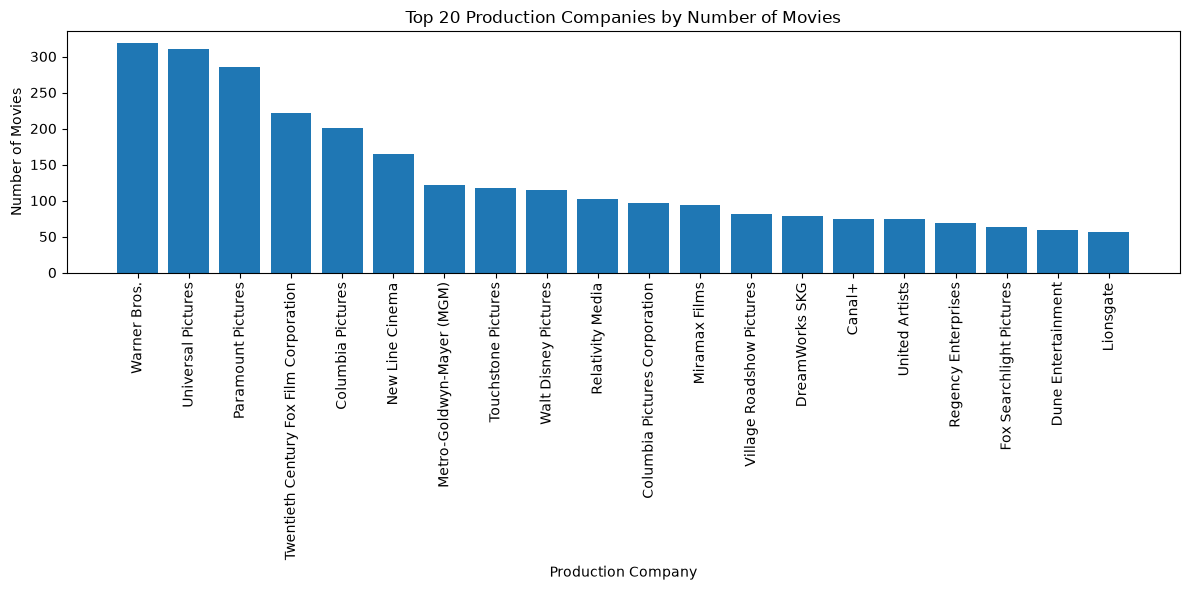

In [155]:
# 📊 Count movie occurrences by production company name
company_counts = Counter()

for companies in companies_parsed:
    for company in companies:
        company_counts[company["name"]] += 1

# 🔝 Top 20 production companies
top_companies = company_counts.most_common(20)

# 📈 Plot
plt.figure(figsize=(12, 6))
plt.bar(
    [company for company, _ in top_companies],
    [count for _, count in top_companies]
)

# 🏷️ Labels and title
plt.title("Top 20 Production Companies by Number of Movies")
plt.xlabel("Production Company")
plt.ylabel("Number of Movies")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Column `production_countries`

In [156]:
# 📊 Display complete examples of the production_countries column
for i, countries in enumerate(merged_df["production_countries"].head(5), start=1):
    print(f"Movie {i}:")
    print(countries)
    print("-" * 100)

Movie 1:
[{"iso_3166_1": "US", "name": "United States of America"}, {"iso_3166_1": "GB", "name": "United Kingdom"}]
----------------------------------------------------------------------------------------------------
Movie 2:
[{"iso_3166_1": "US", "name": "United States of America"}]
----------------------------------------------------------------------------------------------------
Movie 3:
[{"iso_3166_1": "GB", "name": "United Kingdom"}, {"iso_3166_1": "US", "name": "United States of America"}]
----------------------------------------------------------------------------------------------------
Movie 4:
[{"iso_3166_1": "US", "name": "United States of America"}]
----------------------------------------------------------------------------------------------------
Movie 5:
[{"iso_3166_1": "US", "name": "United States of America"}]
----------------------------------------------------------------------------------------------------


#### Missing values

In [158]:
# 📊 Count missing values
missing_countries = merged_df["production_countries"].isna().sum()

# 📊 Count empty country lists
empty_countries = (merged_df["production_countries"] == "[]").sum()

print(f"Missing values (NaN): {missing_countries}")
print(f"Empty country lists ([]): {empty_countries}")

Missing values (NaN): 0
Empty country lists ([]): 174


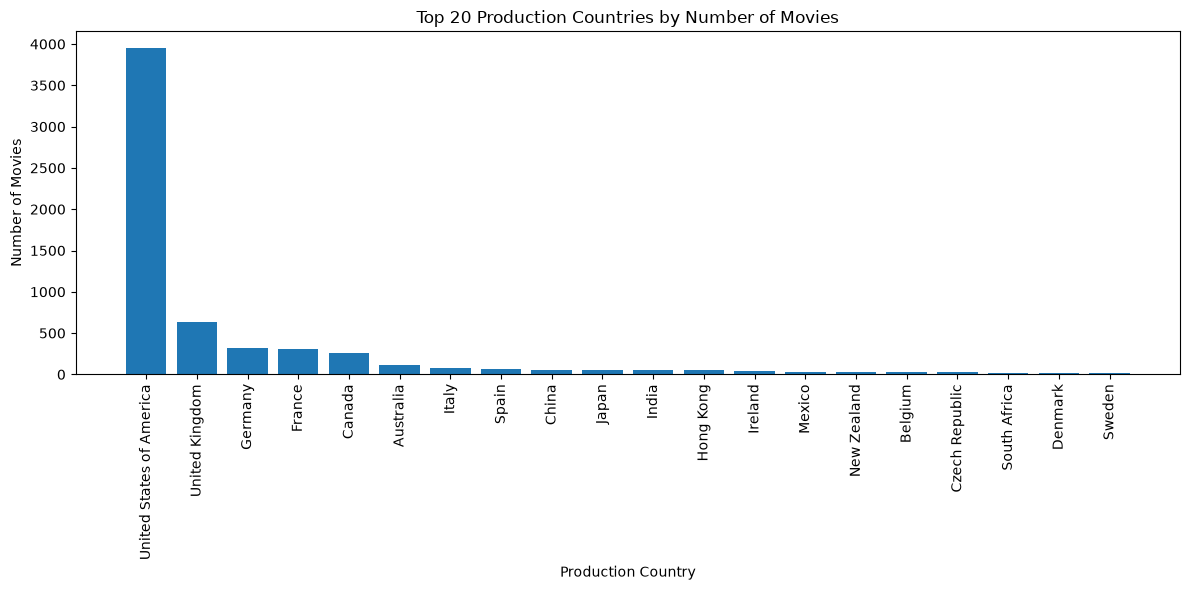

In [157]:
countries_parsed = merged_df["production_countries"].fillna("[]").apply(ast.literal_eval)

# 📊 Count movie occurrences by production country
country_counts = Counter()

for countries in countries_parsed:
    for country in countries:
        country_counts[country["name"]] += 1

# 🔝 Top 20 production countries
top_countries = country_counts.most_common(20)

# 📈 Plot
plt.figure(figsize=(12, 6))
plt.bar(
    [country for country, _ in top_countries],
    [count for _, count in top_countries]
)

# 🏷️ Labels and title
plt.title("Top 20 Production Countries by Number of Movies")
plt.xlabel("Production Country")
plt.ylabel("Number of Movies")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Column `cast`

In [159]:
# 📊 Display complete examples of the cast column
for i, cast in enumerate(merged_df["cast"].head(3), start=1):
    print(f"Movie {i}:")
    print(cast)
    print("-" * 120)

Movie 1:
[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "g

#### Missing values

In [160]:
# 📊 Count missing values
missing_cast = merged_df["cast"].isna().sum()

# 📊 Count empty cast lists
empty_cast = (merged_df["cast"] == "[]").sum()

print(f"Missing values (NaN): {missing_cast}")
print(f"Empty cast lists ([]): {empty_cast}")

Missing values (NaN): 0
Empty cast lists ([]): 43


In [161]:
# 🔍 Display movies with missing or empty cast information
merged_df.loc[
    merged_df["cast"].isna() |
    (merged_df["cast"] == "[]"),
    ["original_title", "release_date", "status", "cast"]
]

,original_title,release_date,status,cast
2601,Barney's Great Adventure,1998-01-01,Released,[]
3670,Running Forever,2015-10-27,Released,[]
3992,Sardaarji,2015-06-26,Released,[]
4009,2016: Obama's America,2012-07-13,Released,[]
4068,Sharkskin,2015-01-01,Released,[]
4118,Hum To Mohabbat Karega,2000-05-26,Released,[]
4247,Me You and Five Bucks,2015-07-07,Released,[]
4305,Down & Out With The Dolls,2003-03-20,Released,[]
4314,Crowsnest,2012-01-01,Released,[]
4322,Sex With Strangers,2002-02-22,Released,[]


The movies with empty cast lists do not follow a specific pattern such as being animated films. They include independent productions, documentaries, and lesser-known titles.

Therefore, these empty lists are most likely due to missing or incomplete metadata in the TMDB database rather than the absence of a cast. Since only a small number of movies are affected, they are kept in the dataset and simply contribute no cast information to the subsequent analysis.

#### Consistency checks for ids

In [162]:
# 📊 Parse cast without modifying the original dataframe
cast_parsed = merged_df["cast"].fillna("[]").apply(ast.literal_eval)

# 📊 Dictionary: actor ID -> set of names
id_to_names = defaultdict(set)

for cast in cast_parsed:
    for member in cast:
        id_to_names[member["id"]].add(member["name"])

# 🔍 IDs associated with multiple actor names
inconsistent_actor_ids = {
    actor_id: names
    for actor_id, names in id_to_names.items()
    if len(names) > 1
}

print(f"Number of inconsistent actor IDs: {len(inconsistent_actor_ids)}")

if inconsistent_actor_ids:
    display(inconsistent_actor_ids)

Number of inconsistent actor IDs: 0


In [163]:
# 📊 Dictionary: actor name -> set of IDs
name_to_ids = defaultdict(set)

for cast in cast_parsed:
    for member in cast:
        name_to_ids[member["name"]].add(member["id"])

# 🔍 Actor names associated with multiple IDs
inconsistent_actor_names = {
    name: ids
    for name, ids in name_to_ids.items()
    if len(ids) > 1
}

print(f"Number of actor names associated with multiple IDs: {len(inconsistent_actor_names)}")

if inconsistent_actor_names:
    display(inconsistent_actor_names)

Number of actor names associated with multiple IDs: 366


{'Matt Clayton': {1207278, 1394474},
 'Sam Harris': {1216356, 1525392},
 'Alex Moore': {122339, 1789097},
 'Daniel Newman': {8323, 1536670},
 'Michael Alexander': {1347286, 1781297},
 'Mandy Moore': {16855, 1710767},
 'Michael Cassidy': {56556, 1349468},
 'Michael Shannon': {335, 1184168},
 'Ian Roberts': {13101, 1224391},
 'John Boswall': {140452, 1213693},
 'Michael Kelly': {50217, 1454084},
 'David Lewis': {4095, 571911},
 'Ashley Johnson': {34486, 129388},
 'Will Smith': {2888, 234120},
 'John Burke': {58510, 1583206},
 'Thomas Arnold': {8207, 1132749},
 'William Wallace': {998535, 1169229},
 'Craig Kelly': {1137037, 1451680},
 'Richard Ashton': {179771, 1741665},
 'David Brown': {1260146, 1653176, 1779569},
 'David Jensen': {60875, 1099080},
 'Stephen Bishop': {55205, 938558},
 'Jackie Johnson': {1397455, 1569054},
 'Ralph Richardson': {12689, 1504582},
 'Jake Johnson': {125168, 543505},
 'Peyton List': {229031, 1254435},
 'Adrian Gonzalez': {933319, 1735573},
 'André Sogliuzzo': 

Unlike previous metadata fields, several actor names are associated with multiple IDs. This does not necessarily indicate an inconsistency in the dataset, as different actors may legitimately share the same name.

The important consistency check is that each actor ID corresponds to a single actor name, which holds throughout the dataset. Therefore, actor IDs remain reliable identifiers, while actor names alone cannot always be assumed to uniquely identify an individual.

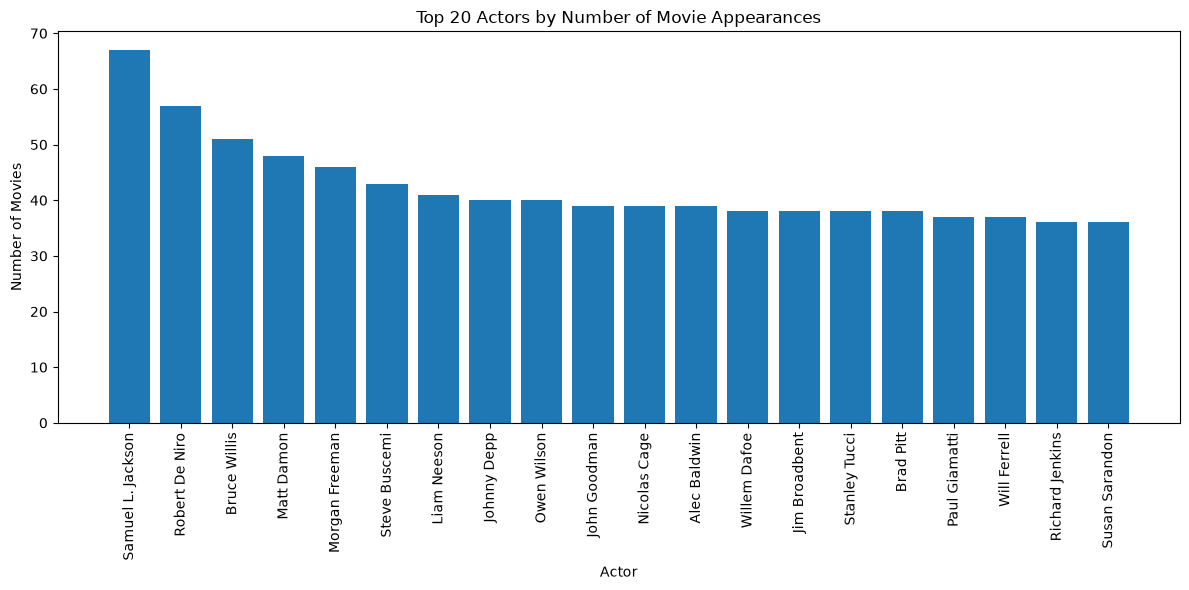

In [164]:
# 📊 Count movie appearances by actor ID
actor_counts = Counter()
actor_names = {}

for cast in cast_parsed:
    for member in cast:
        actor_id = member["id"]
        actor_counts[actor_id] += 1
        actor_names[actor_id] = member["name"]

# 🔝 Top 20 actors by number of movie appearances
top_actors = actor_counts.most_common(20)

# 📈 Plot
plt.figure(figsize=(12, 6))
plt.bar(
    [actor_names[actor_id] for actor_id, _ in top_actors],
    [count for _, count in top_actors]
)

# 🏷️ Labels and title
plt.title("Top 20 Actors by Number of Movie Appearances")
plt.xlabel("Actor")
plt.ylabel("Number of Movies")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Column `crew`

In [165]:
# 📊 Display complete examples of the crew column
for i, crew in enumerate(merged_df["crew"].head(3), start=1):
    print(f"Movie {i}:")
    print(crew)
    print("-" * 120)

Movie 1:
[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Ca

In [166]:
# 📊 Count missing values
missing_crew = merged_df["crew"].isna().sum()

# 📊 Count empty crew lists
empty_crew = (merged_df["crew"] == "[]").sum()

print(f"Missing values (NaN): {missing_crew}")
print(f"Empty crew lists ([]): {empty_crew}")

Missing values (NaN): 0
Empty crew lists ([]): 28


#### Consistency checks for ids

In [168]:
# 📊 Parse crew without modifying the original dataframe
crew_parsed = merged_df["crew"].fillna("[]").apply(ast.literal_eval)

# 📊 Dictionary: crew member ID -> set of names
id_to_names = defaultdict(set)

for crew in crew_parsed:
    for member in crew:
        id_to_names[member["id"]].add(member["name"])

# 🔍 IDs associated with multiple names
inconsistent_ids = {
    person_id: names
    for person_id, names in id_to_names.items()
    if len(names) > 1
}

print(f"Number of inconsistent crew member IDs: {len(inconsistent_ids)}")

if inconsistent_ids:
    display(inconsistent_ids)

Number of inconsistent crew member IDs: 0


In [169]:
# 📊 Dictionary: crew member name -> set of IDs
name_to_ids = defaultdict(set)

for crew in crew_parsed:
    for member in crew:
        name_to_ids[member["name"]].add(member["id"])

# 🔍 Names associated with multiple IDs
inconsistent_names = {
    name: ids
    for name, ids in name_to_ids.items()
    if len(ids) > 1
}

print(f"Number of crew member names associated with multiple IDs: {len(inconsistent_names)}")

if inconsistent_names:
    display(inconsistent_names)

Number of crew member names associated with multiple IDs: 586


{'Simon Bright': {33303, 1180101},
 'John Dixon': {76195, 1259516},
 'Mark Harris': {986687, 1331655, 1632601},
 'David Smith': {27266, 1414096, 1520056},
 'Eddie Murphy': {776, 1551813},
 'Emma Thomas': {556, 1408530},
 'Bruce Fowler': {932186, 1554041},
 'Richard King': {1172813, 1341403},
 'Alison Evans': {1395030, 1454668},
 'Diana Choi': {60239, 1415606},
 'David Butler': {575926, 1417839},
 'Dan Brown': {8404, 1535095},
 'Joe Guzman': {1407030, 1550248},
 'Colin Wilson': {490, 71030, 1282435},
 'John King': {7477, 34513},
 'Colin Anderson': {1400535, 1662332},
 'James Acheson': {11386, 69671},
 'Mark Kennedy': {61414, 1864765},
 'Rick Moore': {1447483, 1882579},
 'Charles Wood': {32349, 444552},
 'Matthew Robinson': {1388855, 1551346},
 "Chris O'Connell": {1412756, 1872881},
 'Tim Lewis': {89320, 1112036},
 'Frank Miller': {2293, 1205954},
 'Bob Morgan': {190776, 1322016},
 'Tom Williams': {213665, 1534987},
 'Jenny Morgan': {1554879, 1660708},
 'Simon Ward': {1497530, 1554885},


In [170]:
# 📊 Dictionary: crew member ID -> set of departments
id_to_departments = defaultdict(set)

for crew in crew_parsed:
    for member in crew:
        id_to_departments[member["id"]].add(member["department"])

multiple_departments = {
    person_id: departments
    for person_id, departments in id_to_departments.items()
    if len(departments) > 1
}

print(f"Crew members working in multiple departments: {len(multiple_departments)}")

if multiple_departments:
    display(multiple_departments)

Crew members working in multiple departments: 5146


{900: {'Crew', 'Sound'},
 2710: {'Directing', 'Editing', 'Production', 'Writing'},
 6883: {'Crew', 'Sound'},
 8159: {'Crew', 'Sound'},
 20294: {'Crew', 'Production', 'Writing'},
 18265: {'Camera', 'Lighting'},
 113145: {'Crew', 'Visual Effects'},
 58188: {'Crew', 'Editing'},
 92359: {'Art', 'Crew'},
 93214: {'Directing', 'Visual Effects'},
 957874: {'Production', 'Visual Effects'},
 959555: {'Art', 'Crew'},
 1032536: {'Art', 'Directing', 'Visual Effects'},
 1202850: {'Art', 'Costume & Make-Up'},
 1271932: {'Crew', 'Visual Effects'},
 1352422: {'Editing', 'Sound'},
 1376901: {'Editing', 'Sound'},
 1376902: {'Editing', 'Sound'},
 1394286: {'Crew', 'Visual Effects'},
 1394750: {'Crew', 'Visual Effects'},
 1394953: {'Editing', 'Visual Effects'},
 1395269: {'Crew', 'Visual Effects'},
 1398970: {'Camera', 'Crew'},
 1401788: {'Crew', 'Visual Effects'},
 1401789: {'Production', 'Visual Effects'},
 1401792: {'Crew', 'Visual Effects'},
 1401794: {'Crew', 'Editing'},
 1401795: {'Crew', 'Visual Ef

Some crew member names are associated with multiple IDs. This is expected and most likely reflects different individuals sharing the same name rather than inconsistencies in the dataset.

Since each ID is consistently linked to a single name, the crew member ID remains the most reliable identifier for distinguishing individuals. Therefore, subsequent analyses identify crew members by their ID while displaying their names for readability.

#### Type of jobs

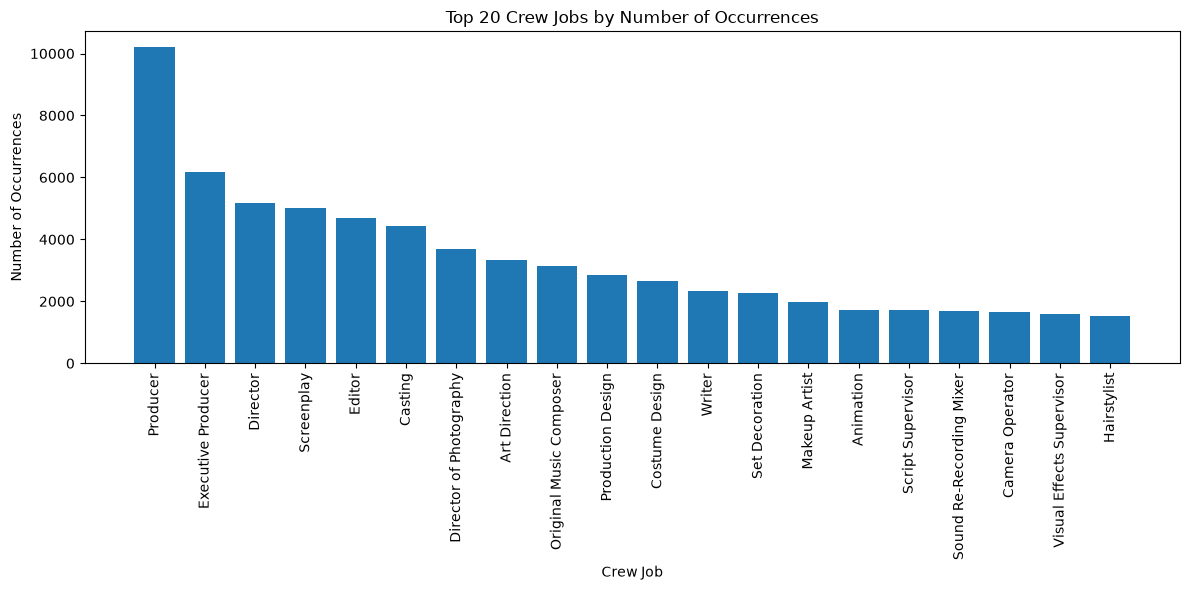

In [174]:
# 📊 Count occurrences of each crew job
job_counts = Counter()

for crew in crew_parsed:
    for member in crew:
        job_counts[member["job"]] += 1

# 🔝 Top 20 most frequent jobs
top_jobs = job_counts.most_common(20)

# 📈 Plot
plt.figure(figsize=(12, 6))
plt.bar(
    [job for job, _ in top_jobs],
    [count for _, count in top_jobs]
)

# 🏷️ Labels and title
plt.title("Top 20 Crew Jobs by Number of Occurrences")
plt.xlabel("Crew Job")
plt.ylabel("Number of Occurrences")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

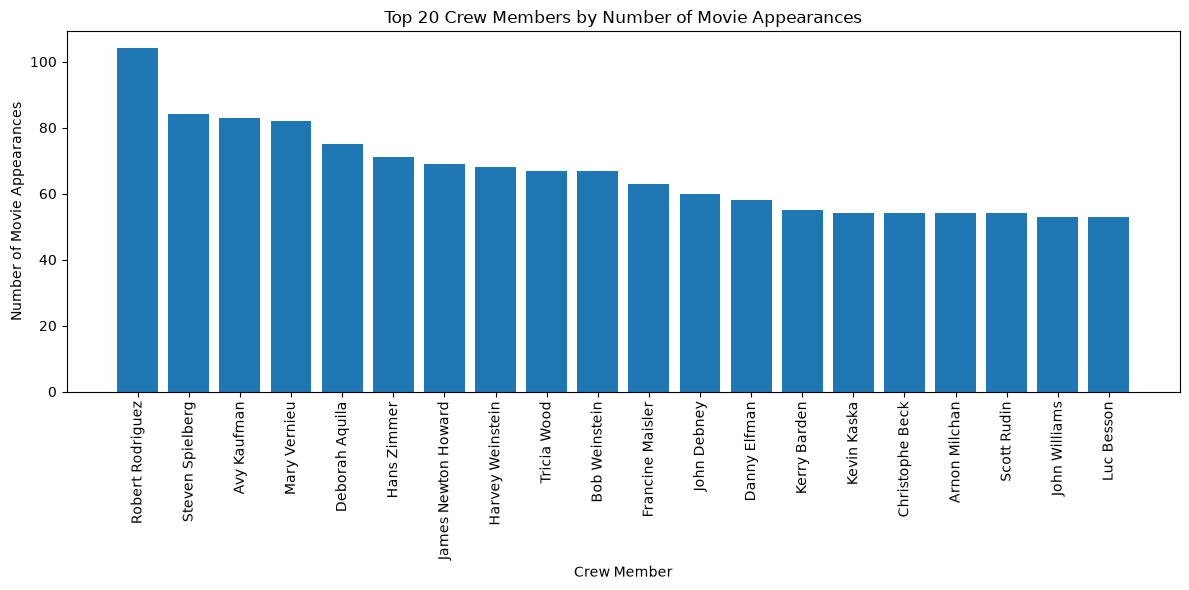

In [175]:
# 📊 Count movie appearances by crew member ID
crew_counts = Counter()
crew_names = {}

for crew in crew_parsed:
    for member in crew:
        person_id = member["id"]
        crew_counts[person_id] += 1
        crew_names[person_id] = member["name"]

# 🔝 Top 20 crew members by number of movie appearances
top_crew = crew_counts.most_common(20)

# 📈 Plot
plt.figure(figsize=(12, 6))
plt.bar(
    [crew_names[person_id] for person_id, _ in top_crew],
    [count for _, count in top_crew]
)

# 🏷️ Labels and title
plt.title("Top 20 Crew Members by Number of Movie Appearances")
plt.xlabel("Crew Member")
plt.ylabel("Number of Movie Appearances")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()